In [8]:
import pandas as pd
import requests
import os

df_ssym = pd.read_csv(r"C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\SSYM\ssym.csv", sep=",")

In [5]:
df_ssym 

,ID,CLUID,PDB,CHAIN,MUT,DDG,pH,T,DIR/INV
0,1,1AMQA,1AMQ,A,C191Y,-2.3,7.5,25.0,DIR
1,1,1AMQA,1QIR,A,Y191C,2.3,7.5,25.0,INV
2,2,1AMQA,1AMQ,A,C191F,-1.6,7.5,25.0,DIR
3,2,1AMQA,1QIS,A,F191C,1.6,7.5,25.0,INV
4,3,1AMQA,1AMQ,A,C191W,-3.9,7.5,25.0,DIR
...,...,...,...,...,...,...,...,...,...
679,340,1BPIA,8PTI,A,G35Y,5.0,2.0,25.0,INV
680,341,1BPIA,5PTI,A,N43G,-5.7,2.0,25.0,DIR
681,341,1BPIA,1NAG,A,G43N,5.7,2.0,25.0,INV
682,342,1BPIA,5PTI,A,F45A,-6.9,2.0,25.0,DIR


In [16]:
unique_targets = df_ssym[['PDB']].drop_duplicates().reset_index(drop=True)

print(f"전체 로우: {len(df_ssym)} -> 처리할 유니크 타겟: {len(unique_targets)}")

전체 로우: 684 -> 처리할 유니크 타겟: 357


In [17]:
unique_targets

,PDB
0,1AMQ
1,1QIR
2,1QIS
3,1QIT
4,5EAA
...,...
352,1BTI
353,1BPT
354,8PTI
355,1NAG


In [21]:
def download_pdb(pdb_id, save_dir="./pdb_files"):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # 결과 저장용 변수
    source = None
    file_path = None

    # 1. RCSB PDB 시도 (PDB_ID가 존재할 때)
    if pd.notna(pdb_id) and pdb_id != 'NaN':
        pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        try:
            res = requests.get(pdb_url)
            if res.status_code == 200:
                file_path = os.path.join(save_dir, f"{pdb_id}.pdb")
                with open(file_path, 'w') as f:
                    f.write(res.text)
                return pdb_id, "RCSB_PDB", file_path
        except:
            pass

    return None, "Failed", None

In [22]:
results = []

for idx, row in unique_targets.iterrows():
    pdb_id = row['PDB']
    
    print(f"[{idx+1}/{len(unique_targets)}] Processing: {pdb_id}...", end='\r')
    
    found_id, source, path = download_pdb(pdb_id)
    results.append({
        'PDB': pdb_id,
        'FETCHED_ID': found_id,
        'STRUCTURE_SOURCE': source,
        'FILE_PATH': path
    })

# 결과를 데이터프레임으로 변환 후 병합
df_results = pd.DataFrame(results)
df_final = pd.merge(df_ssym, df_results, on=['PDB'], how='left')

 [ 수집 결과 요약 ]
     Source  Count  Percentage (%)
0  RCSB_PDB    357           100.0
------------------------------
총 고유 ID 개수: 357
성공: 357 (100.00%)
실패: 0 (0.00%)


C:\Users\Kunny\AppData\Local\Temp\ipykernel_28596\3088962862.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_stats, x='Source', y='Count', palette='viridis')


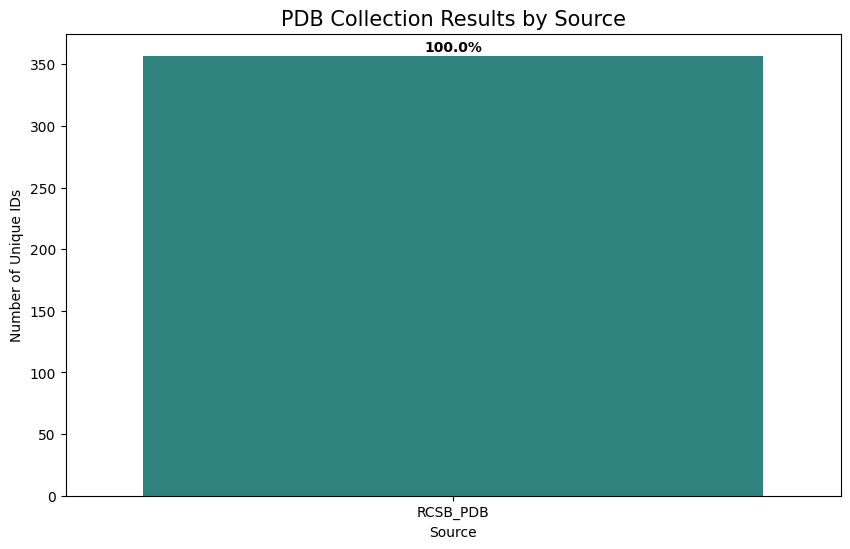

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 소스별 수량 및 비율 계산
source_stats = df_results['STRUCTURE_SOURCE'].value_counts().reset_index()
source_stats.columns = ['Source', 'Count']
source_stats['Percentage (%)'] = (source_stats['Count'] / len(df_results) * 100).round(2)

print(" [ 수집 결과 요약 ]")
print(source_stats)
print("-" * 30)

# 2. 성공률 계산
total = len(df_results)
success = len(df_results[df_results['STRUCTURE_SOURCE'] != 'Failed'])
fail = total - success
print(f"총 고유 ID 개수: {total}")
print(f"성공: {success} ({success/total*100:.2f}%)")
print(f"실패: {fail} ({fail/total*100:.2f}%)")

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))
sns.barplot(data=source_stats, x='Source', y='Count', palette='viridis')
plt.title('PDB Collection Results by Source', fontsize=15)
for i, row in source_stats.iterrows():
    plt.text(i, row['Count'] + (total*0.01), f"{row['Percentage (%)']}%", ha='center', fontweight='bold')
plt.ylabel('Number of Unique IDs')
plt.show()

# 4. 실패한 리스트 따로 뽑아보기 (원인 분석용)
failed_df = df_results[df_results['STRUCTURE_SOURCE'] == 'Failed']
if not failed_df.empty:
    print("\n [ 실패한 UniProt ID (상위 10개) ]")
    print(failed_df['UP_ID_CLEAN'].head(10).tolist())

In [24]:
df_final

,ID,CLUID,PDB,CHAIN,MUT,DDG,pH,T,DIR/INV,FETCHED_ID,STRUCTURE_SOURCE,FILE_PATH
0,1,1AMQA,1AMQ,A,C191Y,-2.3,7.5,25.0,DIR,1AMQ,RCSB_PDB,./pdb_files\1AMQ.pdb
1,1,1AMQA,1QIR,A,Y191C,2.3,7.5,25.0,INV,1QIR,RCSB_PDB,./pdb_files\1QIR.pdb
2,2,1AMQA,1AMQ,A,C191F,-1.6,7.5,25.0,DIR,1AMQ,RCSB_PDB,./pdb_files\1AMQ.pdb
3,2,1AMQA,1QIS,A,F191C,1.6,7.5,25.0,INV,1QIS,RCSB_PDB,./pdb_files\1QIS.pdb
4,3,1AMQA,1AMQ,A,C191W,-3.9,7.5,25.0,DIR,1AMQ,RCSB_PDB,./pdb_files\1AMQ.pdb
...,...,...,...,...,...,...,...,...,...,...,...,...
679,340,1BPIA,8PTI,A,G35Y,5.0,2.0,25.0,INV,8PTI,RCSB_PDB,./pdb_files\8PTI.pdb
680,341,1BPIA,5PTI,A,N43G,-5.7,2.0,25.0,DIR,5PTI,RCSB_PDB,./pdb_files\5PTI.pdb
681,341,1BPIA,1NAG,A,G43N,5.7,2.0,25.0,INV,1NAG,RCSB_PDB,./pdb_files\1NAG.pdb
682,342,1BPIA,5PTI,A,F45A,-6.9,2.0,25.0,DIR,5PTI,RCSB_PDB,./pdb_files\5PTI.pdb


In [32]:
df_final["WT"] = df_final["MUT"].str[0]
df_final["Mut"] = df_final["MUT"].str[-1]
df_final["MutPos"] = df_final["MutPos"].astype(int)

In [ ]:
df_final = df_final.drop(columns=["ID", "pH", "T", "STRUCTURE_SOURCE", "CLUID", "MUT", "FETCHED_ID"])

In [42]:
df_final

,PDB,CHAIN,DDG,DIR/INV,FILE_PATH,WT,Mut,MutPos
0,1AMQ,A,-2.3,DIR,./pdb_files\1AMQ.pdb,C,Y,191
1,1QIR,A,2.3,INV,./pdb_files\1QIR.pdb,Y,C,191
2,1AMQ,A,-1.6,DIR,./pdb_files\1AMQ.pdb,C,F,191
3,1QIS,A,1.6,INV,./pdb_files\1QIS.pdb,F,C,191
4,1AMQ,A,-3.9,DIR,./pdb_files\1AMQ.pdb,C,W,191
...,...,...,...,...,...,...,...,...
679,8PTI,A,5.0,INV,./pdb_files\8PTI.pdb,G,Y,35
680,5PTI,A,-5.7,DIR,./pdb_files\5PTI.pdb,N,G,43
681,1NAG,A,5.7,INV,./pdb_files\1NAG.pdb,G,N,43
682,5PTI,A,-6.9,DIR,./pdb_files\5PTI.pdb,F,A,45


In [54]:
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import three_to_one, is_aa

def verify_with_chain_mapping(row):
    if pd.isna(row['FILE_PATH']):
        return "No_File", None
    
    up_id = row['PDB']
    target_pos = int(row['MutPos'])
    target_wt = row['WT']
    chain_id = row["CHAIN"]

    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure('protein', row['FILE_PATH'])
        model = structure[0]
        
        # 1. 모델 안에 해당 체인 ID가 있는지 먼저 확인
        if chain_id not in model:
            return "Chain_Not_Found", None
            
        chain_obj = model[chain_id] # 실제 Bio.PDB의 Chain 객체 추출

        # 2. 해당 위치(target_pos)에 잔기가 있는지 확인
        # PDB는 (hetero-flag, resseq, insertion_code) 튜플을 키로 사용함
        # 일반적인 아미노산은 (' ', target_pos, ' ') 구조입니다.
        res_key = (' ', target_pos, ' ')
        
        if res_key in chain_obj:
            res = chain_obj[res_key]
            if is_aa(res):
                res_name_1 = three_to_one(res.get_resname())
                
                if res_name_1 == target_wt:
                    return "Match", chain_id
                else:
                    return f"Mismatch(Found:{res_name_1})", chain_id
        
        return "Position_Not_Found", None
        
    except Exception as e:
        return f"Error: {str(e)}", None

# 적용 (결과가 2개이므로 zip 사용)
print("정밀 체인 매핑 시작...")
results = df_final.apply(verify_with_chain_mapping, axis=1)
df_final[['MAPPING_STATUS', 'MATCHED_CHAIN']] = pd.DataFrame(results.tolist(), index=df_final.index)

정밀 체인 매핑 시작...


=== [ 매핑 실패 원인 통계 ] ===
Empty DataFrame
Columns: [Failure_Reason, Count, Percentage (%)]
Index: []
----------------------------------------


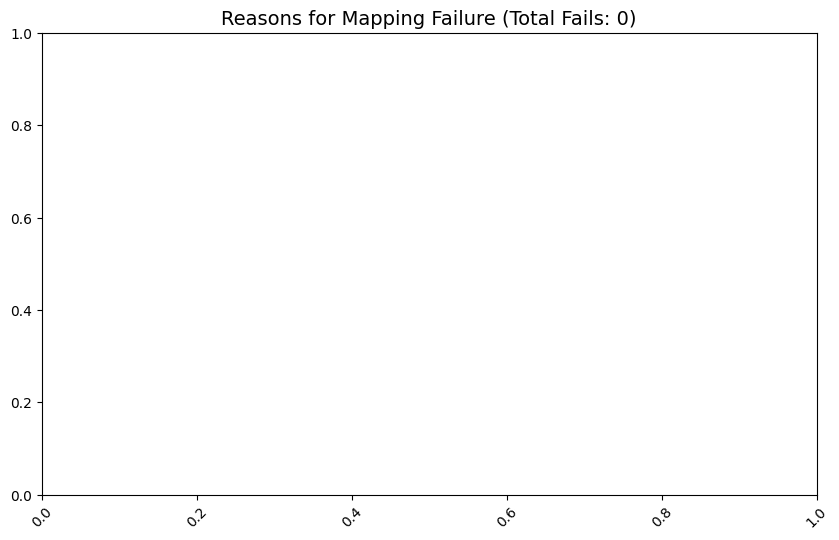

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 실패한 데이터만 추출
df_fail = df_final[df_final["MAPPING_STATUS"] != "Match"].copy()

# 2. 실패 원인별 통계 (Value Counts)
fail_stats = df_fail["MAPPING_STATUS"].value_counts().reset_index()
fail_stats.columns = ['Failure_Reason', 'Count']
fail_stats['Percentage (%)'] = (fail_stats['Count'] / len(df_fail) * 100).round(2)

print("=== [ 매핑 실패 원인 통계 ] ===")
print(fail_stats)
print("-" * 40)

# 3. 주요 원인 분석 가이드
# - No_File: PDB/AlphaFold 다운로드 자체를 실패함 (네트워크 혹은 ID 부재)
# - POS_Not_Found: 구조 파일은 있으나, 해당 POS 번호가 구조 내에 없음 (주로 RCSB PDB의 결실 영역)
# - Mismatch(X): 번호는 있으나 해당 위치의 아미노산이 다름 (주로 RCSB PDB의 번호 밀림 이슈)

# 4. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=fail_stats, x='Failure_Reason', y='Count', palette='magma')
plt.title(f"Reasons for Mapping Failure (Total Fails: {len(df_fail)})", fontsize=14)
for i, row in fail_stats.iterrows():
    plt.text(i, row['Count'] + (len(df_fail)*0.01), f"{row['Percentage (%)']}%", ha='center')
plt.xticks(rotation=45)
plt.show()

In [56]:
df_final

,PDB,CHAIN,DDG,DIR/INV,FILE_PATH,WT,Mut,MutPos,MAPPING_STATUS,MATCHED_CHAIN
0,1AMQ,A,-2.3,DIR,./pdb_files\1AMQ.pdb,C,Y,191,Match,A
1,1QIR,A,2.3,INV,./pdb_files\1QIR.pdb,Y,C,191,Match,A
2,1AMQ,A,-1.6,DIR,./pdb_files\1AMQ.pdb,C,F,191,Match,A
3,1QIS,A,1.6,INV,./pdb_files\1QIS.pdb,F,C,191,Match,A
4,1AMQ,A,-3.9,DIR,./pdb_files\1AMQ.pdb,C,W,191,Match,A
...,...,...,...,...,...,...,...,...,...,...
679,8PTI,A,5.0,INV,./pdb_files\8PTI.pdb,G,Y,35,Match,A
680,5PTI,A,-5.7,DIR,./pdb_files\5PTI.pdb,N,G,43,Match,A
681,1NAG,A,5.7,INV,./pdb_files\1NAG.pdb,G,N,43,Match,A
682,5PTI,A,-6.9,DIR,./pdb_files\5PTI.pdb,F,A,45,Match,A


In [59]:
df_final = df_final.rename(columns={
    "MUT": "Mut",
    "PDB": "PDB_ID",
    "CHAIN": "Chain"
})

df_final = df_final.drop(columns = ["MAPPING_STATUS", "MATCHED_CHAIN"])

df_final

,PDB_ID,Chain,DDG,DIR/INV,FILE_PATH,WT,Mut,MutPos
0,1AMQ,A,-2.3,DIR,./pdb_files\1AMQ.pdb,C,Y,191
1,1QIR,A,2.3,INV,./pdb_files\1QIR.pdb,Y,C,191
2,1AMQ,A,-1.6,DIR,./pdb_files\1AMQ.pdb,C,F,191
3,1QIS,A,1.6,INV,./pdb_files\1QIS.pdb,F,C,191
4,1AMQ,A,-3.9,DIR,./pdb_files\1AMQ.pdb,C,W,191
...,...,...,...,...,...,...,...,...
679,8PTI,A,5.0,INV,./pdb_files\8PTI.pdb,G,Y,35
680,5PTI,A,-5.7,DIR,./pdb_files\5PTI.pdb,N,G,43
681,1NAG,A,5.7,INV,./pdb_files\1NAG.pdb,G,N,43
682,5PTI,A,-6.9,DIR,./pdb_files\5PTI.pdb,F,A,45


In [61]:
df_final['FILE_PATH'] = df_final['FILE_PATH'].apply(lambda x: os.path.basename(x))

df_final

,PDB_ID,Chain,DDG,DIR/INV,FILE_PATH,WT,Mut,MutPos
0,1AMQ,A,-2.3,DIR,1AMQ.pdb,C,Y,191
1,1QIR,A,2.3,INV,1QIR.pdb,Y,C,191
2,1AMQ,A,-1.6,DIR,1AMQ.pdb,C,F,191
3,1QIS,A,1.6,INV,1QIS.pdb,F,C,191
4,1AMQ,A,-3.9,DIR,1AMQ.pdb,C,W,191
...,...,...,...,...,...,...,...,...
679,8PTI,A,5.0,INV,8PTI.pdb,G,Y,35
680,5PTI,A,-5.7,DIR,5PTI.pdb,N,G,43
681,1NAG,A,5.7,INV,1NAG.pdb,G,N,43
682,5PTI,A,-6.9,DIR,5PTI.pdb,F,A,45


In [62]:
print(df_final)

    PDB_ID Chain  DDG DIR/INV FILE_PATH WT Mut  MutPos
0     1AMQ     A -2.3     DIR  1AMQ.pdb  C   Y     191
1     1QIR     A  2.3     INV  1QIR.pdb  Y   C     191
2     1AMQ     A -1.6     DIR  1AMQ.pdb  C   F     191
3     1QIS     A  1.6     INV  1QIS.pdb  F   C     191
4     1AMQ     A -3.9     DIR  1AMQ.pdb  C   W     191
..     ...   ...  ...     ...       ... ..  ..     ...
679   8PTI     A  5.0     INV  8PTI.pdb  G   Y      35
680   5PTI     A -5.7     DIR  5PTI.pdb  N   G      43
681   1NAG     A  5.7     INV  1NAG.pdb  G   N      43
682   5PTI     A -6.9     DIR  5PTI.pdb  F   A      45
683   1FAN     A  6.9     INV  1FAN.pdb  A   F      45

[684 rows x 8 columns]


In [63]:
import os
import pandas as pd
from Bio import PDB
from Bio.PDB.Polypeptide import three_to_one, is_aa

# 경로 설정
pdb_dir = r"C:\Users\Kunny\Documents\GitHub\CAGI\EvoStructCLIP\SSYM\pdb_files"
output_fasta = "ssym.fasta"

def get_fasta_and_mapping(pdb_path, target_chain_id):
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_path)
    
    # PDB 파일 내의 SEQRES 서열 가져오기
    ppb = PDB.PPBuilder()
    seq_list = []
    # SEQRES로부터 서열을 가져오는 것이 가장 정확한 전체 서열 복원 방법입니다.
    # 하지만 일부 PDB는 SEQRES가 없으므로 CA atom 기반으로 복원 후 보정합니다.
    for pp in ppb.build_peptides(structure[0][target_chain_id]):
        seq_list.append(str(pp.get_sequence()))
    
    full_sequence = "".join(seq_list)
    
    # Residue ID(MutPos)와 FASTA Index(1-based) 매핑 테이블 생성
    mapping = {}
    current_idx = 1
    chain = structure[0][target_chain_id]
    
    # ATOM 레코드에 존재하는 잔기들만 순회
    for residue in chain:
        if is_aa(residue):
            res_id = residue.get_id()[1] # PDB상의 숫자 (MutPos)
            mapping[res_id] = current_idx
            current_idx += 1
            
    return full_sequence, mapping

# 결과를 담을 리스트
fasta_entries = {}
seq_pos_list = []

print("서열 추출 및 매핑 시작...")

for idx, row in df_final.iterrows():
    pdb_id = row['PDB_ID']
    chain_id = row['Chain']
    mut_pos = int(row['MutPos'])
    file_path = os.path.join(pdb_dir, row['FILE_PATH'])
    
    if not os.path.exists(file_path):
        seq_pos_list.append(None)
        continue

    try:
        # FASTA 서열과 매핑 정보 가져오기
        if pdb_id not in fasta_entries:
            seq, mapping = get_fasta_and_mapping(file_path, chain_id)
            fasta_entries[pdb_id] = seq
            # 매핑 정보를 임시 저장 (동일 PDB 내 계산 속도 향상)
            fasta_entries[f"{pdb_id}_map"] = mapping
        
        # SeqPos 결정
        current_mapping = fasta_entries[f"{pdb_id}_map"]
        seq_pos = current_mapping.get(mut_pos, None)
        seq_pos_list.append(seq_pos)
        
    except Exception as e:
        print(f"Error processing {pdb_id}: {e}")
        seq_pos_list.append(None)

# 데이터프레임 업데이트
df_final['SeqPos'] = seq_pos_list

# FASTA 파일 저장
with open(output_fasta, "w") as f:
    for pdb_id, sequence in fasta_entries.items():
        if not pdb_id.endswith("_map"): # 매핑 데이터 제외
            f.write(f">{pdb_id}\n{sequence}\n")

print(f"완료! FASTA 파일이 '{output_fasta}'로 저장되었습니다.")

서열 추출 및 매핑 시작...
완료! FASTA 파일이 'ssym.fasta'로 저장되었습니다.


In [66]:
df_final["Key"] = df_final["PDB_ID"]

In [68]:
df_final.to_csv("ssym_processed.tsv", sep='\t', index=False)